HOUSE PRICE PREDICTION: Advanced Regression Techniques


Goal of the Project : Predict the price of a house by its features.If you are a buyer or seller of the house but you don't know the exact price of the house,so supervised machine learning regression algorithms can help you to predict the price of the house just providing features of the target house.




Import essential libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
train=pd.read_csv('/content/Housing.csv')
test=pd.read_csv('/content/Housing.csv')
print('shape of train:',train.shape)
print('shape of test:',test.shape)

shape of train: (545, 13)
shape of test: (545, 13)


In [ ]:
train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
test.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
#concat train and test
df=pd.concat((train,test))
temp_df=df
print('shape of df:',df.shape)

shape of df: (1090, 13)


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


Exploring Data Analysis (EDA)

In [ ]:
#to show all the columns
pd.set_option('display.max_columns',2000)
pd.set_option('display.max_rows',85)

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             1090 non-null   int64 
 1   area              1090 non-null   int64 
 2   bedrooms          1090 non-null   int64 
 3   bathrooms         1090 non-null   int64 
 4   stories           1090 non-null   int64 
 5   mainroad          1090 non-null   object
 6   guestroom         1090 non-null   object
 7   basement          1090 non-null   object
 8   hotwaterheating   1090 non-null   object
 9   airconditioning   1090 non-null   object
 10  parking           1090 non-null   int64 
 11  prefarea          1090 non-null   object
 12  furnishingstatus  1090 non-null   object
dtypes: int64(6), object(7)
memory usage: 119.2+ KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,1.090000e+03,1090.000000,1090.000000,1090.000000,1090.000000,1090.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.869581e+06,2169.144402,0.737725,0.502239,0.867094,0.861190
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.select_dtypes(include=['int64','float64']).columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [ ]:
df.select_dtypes(include=['object']).columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
#set index as ID column
df=df.set_index('price')

In [ ]:
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,
13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


<Axes: ylabel='price'>

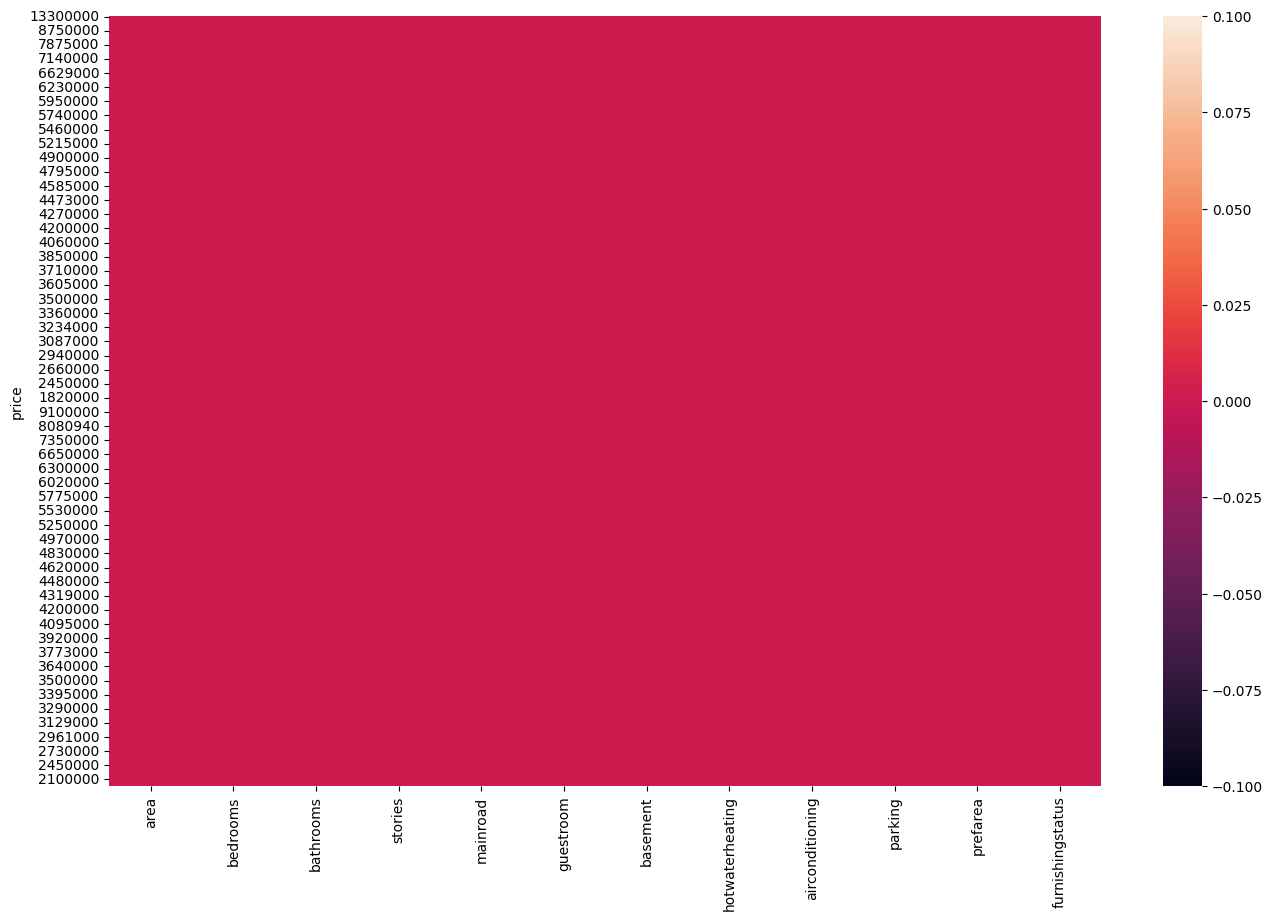

In [ ]:
#show the null values using heatmap
plt.figure(figsize=(16,10))
sns.heatmap(df.isnull())

In [ ]:
#get the percentage of null value
null_percent=df.isnull().sum()/df.shape[0]*100
null_percent

,0
area,0.0
bedrooms,0.0
bathrooms,0.0
stories,0.0
mainroad,0.0
guestroom,0.0
basement,0.0
hotwaterheating,0.0
airconditioning,0.0
parking,0.0


In [ ]:
col_for_drop=null_percent[null_percent>20].keys() #if the null value>20 so need to drop it

In [ ]:
#drop columns
df=df.drop(columns=col_for_drop)
df.shape

(1090, 12)

In [ ]:
#find the unique value count
for i in df.columns:
    print(i + '\t '+ str(len(df[i].unique())))

area	 284
bedrooms	 6
bathrooms	 4
stories	 4
mainroad	 2
guestroom	 2
basement	 2
hotwaterheating	 2
airconditioning	 2
parking	 4
prefarea	 2
furnishingstatus	 3


In [ ]:
#find unique values of each column
for i in df.columns:
    print('unique value of:{} ({}) \n {} \n'.format(i, len(df[i].unique()),df[i].unique()))

unique value of:area (284) 
 [ 7420  8960  9960  7500  8580 16200  8100  5750 13200  6000  6550  3500
  7800  6600  8500  4600  6420  4320  7155  8050  4560  8800  6540  8875
  7950  5500  7475  7000  4880  5960  6840  7482  9000  6360  6480  4300
  7440  6325  5150 11440  7680  8880  6240 11175  7700 12090  4000  5020
  4040  4260  6500  5700 10500  3760  8250  6670  3960  7410  5000  6750
  4800  7200  4100  6400  6350  4500  5450  3240  6615  8372  9620  6800
  8000  6900  3700  7020  7231  6254  7320  6525 15600  7160 11460  5828
  5200  5400  4640  5800  6660  4700  5136  4400  3300  3650  6100  2817
  7980  3150  6210  6825  6710  6450 10269  8400  5300  3800  9800  8520
  6050  7085  3180  3410  3000 11410  5720  3540  7600 10700  8150  4410
  7686  2800  5948  4200  4520  4095  4120  4770  6300  2970  6720  4646
 12900  3420  4995  4350  4160  6040  6862  4815  9166  6321 10240  6440
  5170  3630  9667  3745  3880  5680  2870  5010  4510  3840  3640  2550
  5320  5360  3520  49

In [ ]:
#describe the target
train['bedrooms'].describe()

,bedrooms
count,545.000000
mean,2.965138
std,0.738064
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,6.000000


<ipython-input-27-4445142a2612>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  bar=sns.distplot(train['bedrooms']) # Changed 'bedroom' to 'bedrooms'


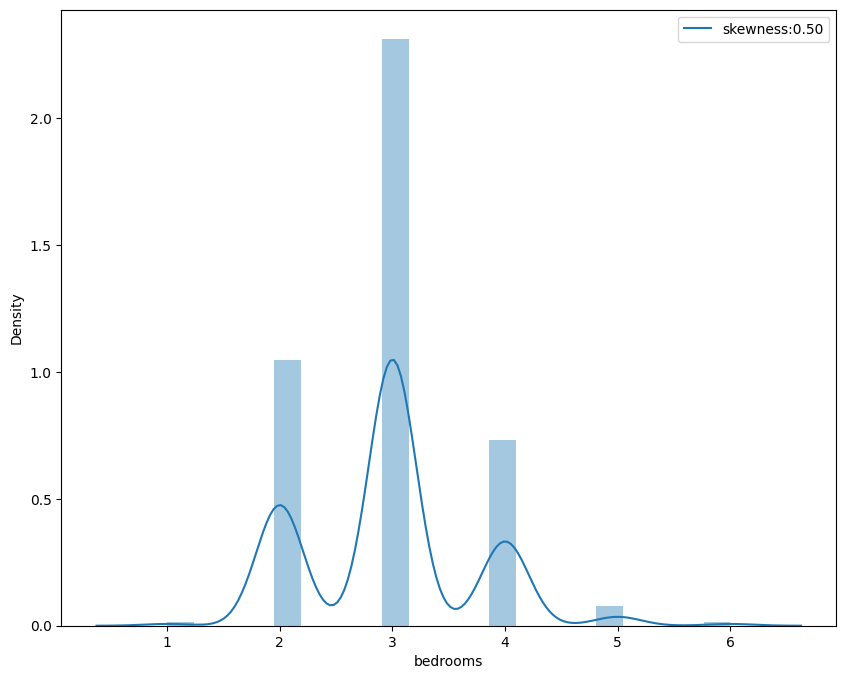

In [ ]:
#plot the displot of target
plt.figure(figsize=(10,8))
bar=sns.distplot(train['bedrooms']) # Changed 'bedroom' to 'bedrooms'
bar.legend(['skewness:{:.2f}'.format(train['bedrooms'].skew())]) # Changed 'bedroom' to 'bedrooms'

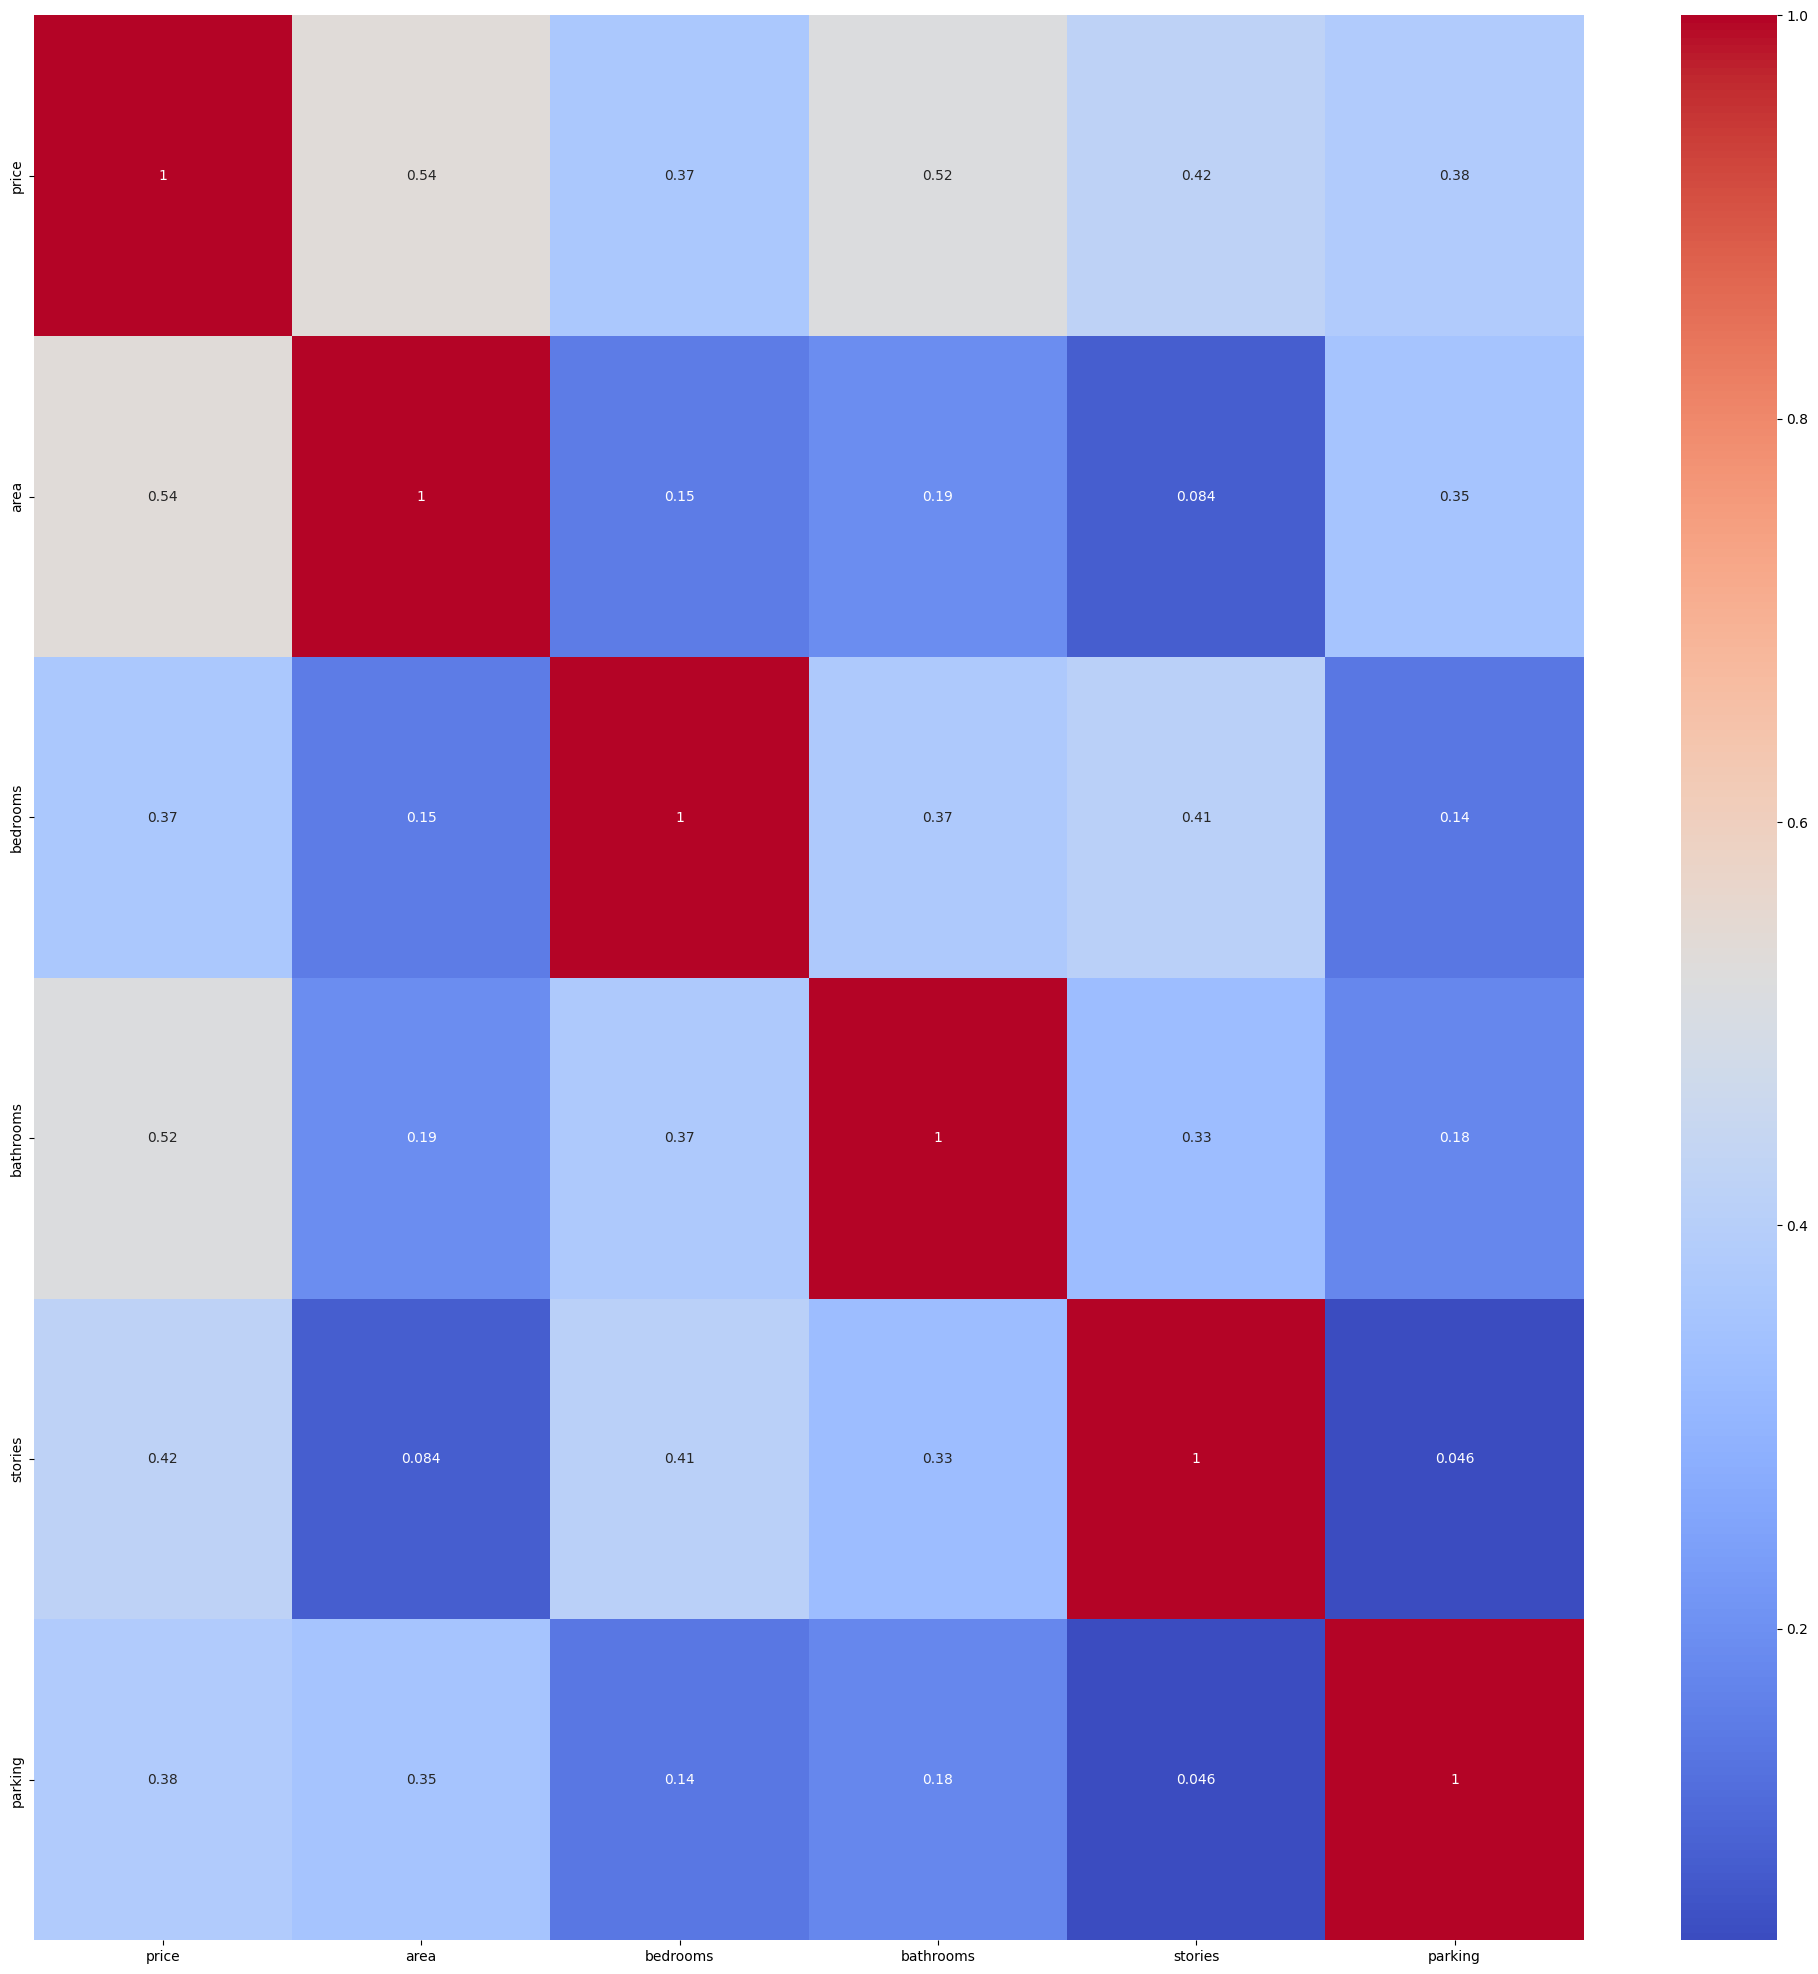

In [ ]:
#correlation heatmap
plt.figure(figsize=(25,25))
# Include only numerical features for correlation calculation
numerical_features = train.select_dtypes(include=['number'])
ax = sns.heatmap(numerical_features.corr(), cmap='coolwarm', annot=True)
plt.show()

In [ ]:
#correlation heatmap of highly correlated features with SalePrice
high_corr = train.select_dtypes(include=['number']).corr()
high_corr_features = high_corr.index[abs(high_corr['price']) >= 0.5]
high_corr_features

Index(['price', 'area', 'bathrooms'], dtype='object')

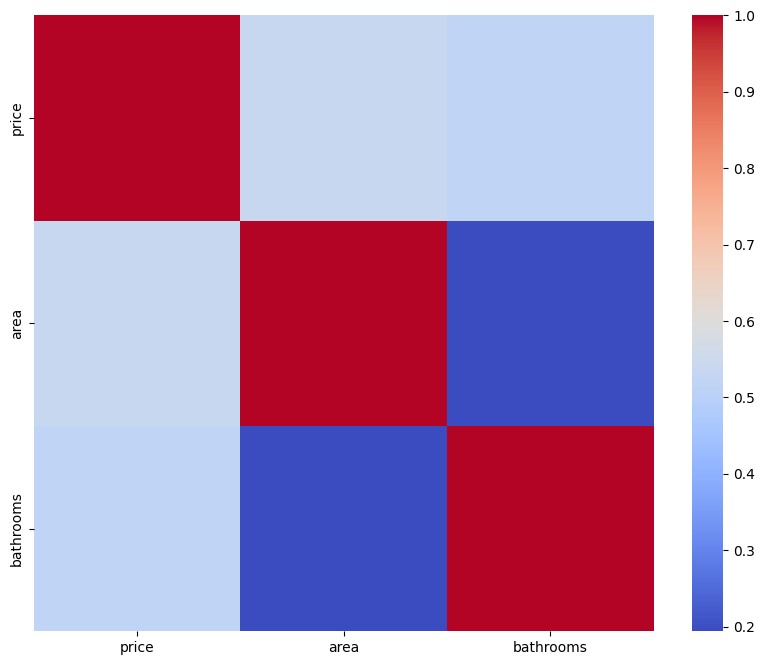

In [ ]:
#correlation heatmap
plt.figure(figsize=(10,8))
ax=sns.heatmap(train[high_corr_features].corr(),cmap='coolwarm')



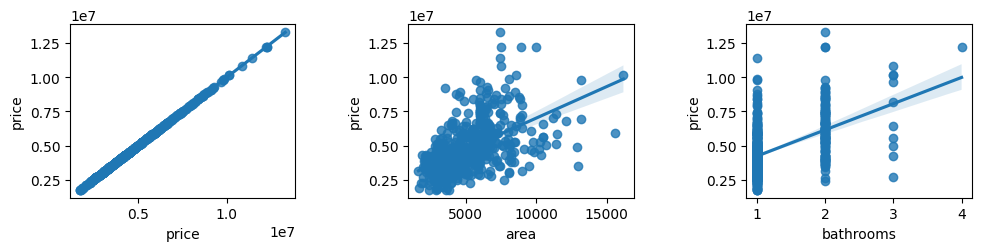

In [ ]:
#plot regplot to get the nature of highly correlated data
plt.figure(figsize=(16,9))
for i in range(len(high_corr_features)):
    if i<=9:
        plt.subplot(3,4,i+1)
        plt.subplots_adjust(hspace=0.5,wspace=0.5)
        sns.regplot(data=train,x=high_corr_features[i],y='price')

Handling Missing Values

In [ ]:
missing_col=df.columns[df.isnull().any()]
missing_col

Index([], dtype='object')

In [ ]:

bsmt_col=['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
bsmt_feat=df[bsmt_col]
bsmt_feat

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,
13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [ ]:

bsmt_feat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 13300000 to 1750000
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   area              1090 non-null   int64 
 1   bedrooms          1090 non-null   int64 
 2   bathrooms         1090 non-null   int64 
 3   stories           1090 non-null   int64 
 4   mainroad          1090 non-null   object
 5   guestroom         1090 non-null   object
 6   basement          1090 non-null   object
 7   hotwaterheating   1090 non-null   object
 8   airconditioning   1090 non-null   object
 9   parking           1090 non-null   int64 
 10  prefarea          1090 non-null   object
 11  furnishingstatus  1090 non-null   object
dtypes: int64(5), object(7)
memory usage: 110.7+ KB


In [ ]:
bsmt_feat.isnull().sum()

,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0
parking,0


In [ ]:
bsmt_feat=bsmt_feat[bsmt_feat.isnull().any(axis=1)] # Changed axis to 1 to filter rows with any null values

In [ ]:
bsmt_feat_all_nan=bsmt_feat[(bsmt_feat.isnull()| bsmt_feat.isin([0])).all(1)]
bsmt_feat_all_nan

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,


In [ ]:
bsmt_feat_all_nan.shape

(0, 12)

In [ ]:
qual=list(df.loc[:,df.dtypes=='object'].columns.values)
qual

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [ ]:
#filling the missing value in bsmt features
for i in bsmt_col:
    if i in qual:
        bsmt_feat_all_nan[i]=bsmt_feat_all_nan[i].replace(np.nan,'NA') #replace the NAN value by 'NA'
    else:
        bsmt_feat_all_nan[i]=bsmt_feat_all_nan[i].replace(np.nan,0) #replace the NAN value inplace of 0
bsmt_feat.update(bsmt_feat_all_nan) #update bsmt_feat df by bsmt_feat_all_nan
df.update(bsmt_feat_all_nan)

In [ ]:

bsmt_feat=bsmt_feat[bsmt_feat.isin([np.nan]).any(axis=1)]
bsmt_feat


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,


In [ ]:

bsmt_feat.shape


(0, 12)

In [ ]:

print(df['stories'].max())
print(df['stories'].min())

4
1


In [ ]:

pd.cut(range(0,1526),5) #create a bucket

[(-1.525, 305.0], (-1.525, 305.0], (-1.525, 305.0], (-1.525, 305.0], (-1.525, 305.0], ..., (1220.0, 1525.0], (1220.0, 1525.0], (1220.0, 1525.0], (1220.0, 1525.0], (1220.0, 1525.0]]
Length: 1526
Categories (5, interval[float64, right]): [(-1.525, 305.0] < (305.0, 610.0] < (610.0, 915.0] <
                                           (915.0, 1220.0] < (1220.0, 1525.0]]

In [ ]:
df_slice=df[(df['stories']>=305)&(df['stories']<=610)]
df_slice

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,


In [ ]:
# Check if the mode Series is empty before accessing it
mode_value = df[df['bathrooms'] == 'Gd']['mainroad'].mode()
if not mode_value.empty:
    bsmt_feat['bathrooms'] = bsmt_feat['mainroad'].replace(np.nan, mode_value[0])
else:
    # Handle the case where the mode Series is empty, e.g., fill with a default value
    bsmt_feat['bathrooms'] = bsmt_feat['mainroad'].replace(np.nan, 'default_value')

In [ ]:

bsmt_feat

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,


In [ ]:

df.update(bsmt_feat)

handling missing value of remain features

In [ ]:
df.columns[df.isnull().any()]

Index([], dtype='object')

In [ ]:
# Reset the index to bring 'price' back as a column
df = df.reset_index()

# Now you can fill NaN values
df['price']=df['price'].fillna(df['price'].mode()[0])
df['area']=df['area'].fillna(df['area'].mode()[0])
df['bedrooms']=df['bedrooms'].fillna(df['bedrooms'].mode()[0])
df['bathrooms']=df['bathrooms'].fillna(df['bathrooms'].mode()[0])
df['stories']=df['stories'].fillna(df['stories'].mode()[0])
df['mainroad']=df['mainroad'].fillna(df['mainroad'].mode()[0])
df['guestroom']=df['guestroom'].fillna(df['guestroom'].mode()[0])
df['basement']=df['basement'].fillna(df['basement'].mode()[0])
df['hotwaterheating']=df['hotwaterheating'].fillna(df['hotwaterheating'].mode()[0])
df['airconditioning']=df['airconditioning'].fillna(df['airconditioning'].mode()[0])
df['parking']=df['parking'].fillna(df['parking'].mode()[0])
df['prefarea']=df['prefarea'].fillna(df['prefarea'].mode()[0])
df['furnishingstatus']=df['furnishingstatus'].fillna(df['furnishingstatus'].mode()[0])

In [ ]:
df.columns[df.isnull().any()]

Index([], dtype='object')

In [ ]:

df[df['parking'].isnull()==True]['parking'].unique()

array([], dtype=int64)

In [ ]:
df.loc[(df['prefarea']=='None')&(df['prefarea'].isnull()==True),'prefarea']=0

In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
price,0.0
area,0.0
bedrooms,0.0
bathrooms,0.0
stories,0.0
mainroad,0.0
guestroom,0.0
basement,0.0
hotwaterheating,0.0
airconditioning,0.0


convert categorical code into order

In [ ]:
df['price'].unique()

array([13300000, 12250000, 12215000, 11410000, 10850000, 10150000,
        9870000,  9800000,  9681000,  9310000,  9240000,  9100000,
        8960000,  8890000,  8855000,  8750000,  8680000,  8645000,
        8575000,  8540000,  8463000,  8400000,  8295000,  8190000,
        8120000,  8080940,  8043000,  7980000,  7962500,  7910000,
        7875000,  7840000,  7700000,  7560000,  7525000,  7490000,
        7455000,  7420000,  7350000,  7343000,  7245000,  7210000,
        7140000,  7070000,  7035000,  7000000,  6930000,  6895000,
        6860000,  6790000,  6755000,  6720000,  6685000,  6650000,
        6629000,  6615000,  6580000,  6510000,  6475000,  6440000,
        6419000,  6405000,  6300000,  6293000,  6265000,  6230000,
        6195000,  6160000,  6125000,  6107500,  6090000,  6083000,
        6020000,  5950000,  5943000,  5880000,  5873000,  5866000,
        5810000,  5803000,  5775000,  5740000,  5652500,  5600000,
        5565000,  5530000,  5523000,  5495000,  5460000,  5425

show skewness of feature with distplot

In [ ]:
skewed_features=['area','bedrooms',	'bathrooms',	'stories',	'mainroad',	'guestroom',	'basement',	'hotwaterheating',	'airconditioning',	'parking',	'prefarea'	,'furnishingstatus',
                 'price']


In [ ]:
# Assuming quan should be assigned to skewed_features for comparison
quan = skewed_features  # Assign skewed_features to quan
quan == skewed_features  # Now the comparison will work

True

<ipython-input-60-ca44c8f0f8ed>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(df[skewed_features[i]])
<ipython-input-60-ca44c8f0f8ed>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(df[skewed_features[i]])
<ipython-input-60-ca44c8f0f8ed>:8: UserWarning: 

`distplot` is a deprecated fun

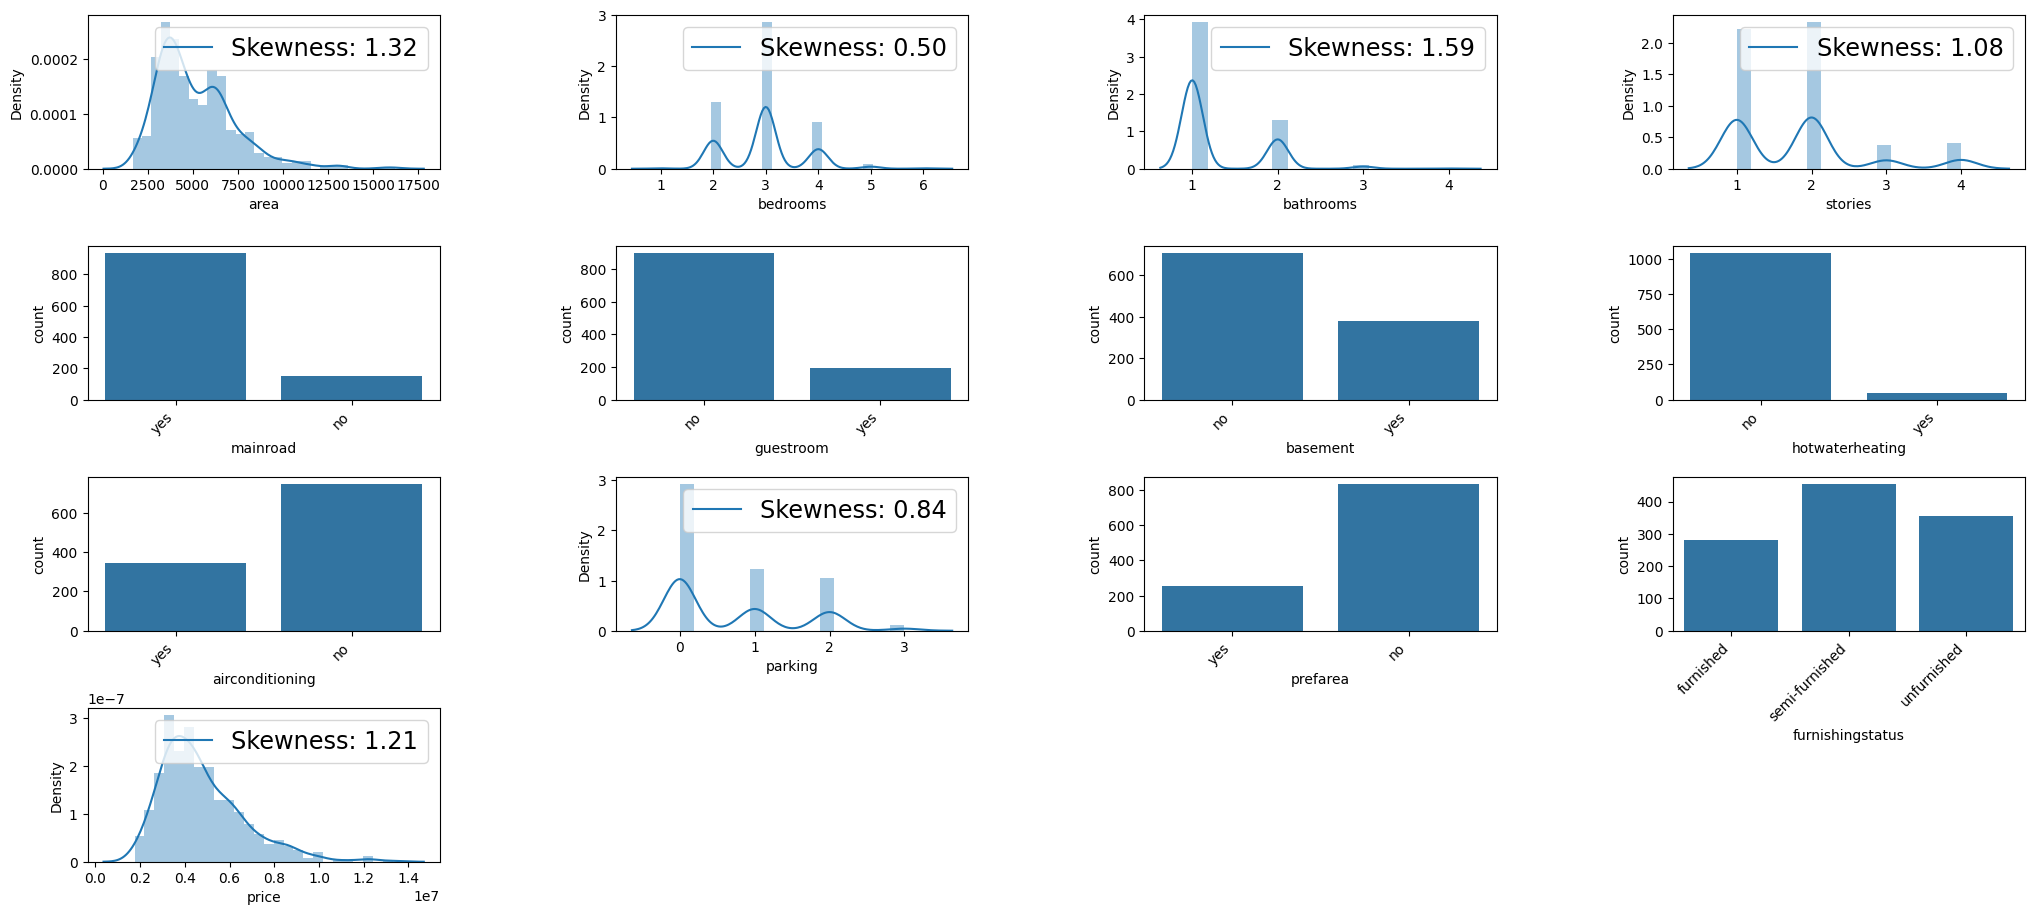

In [ ]:
plt.figure(figsize=(25,20))
for i in range(len(skewed_features)):
    if i<=28:
        plt.subplot(7,4,i+1)
        plt.subplots_adjust(hspace=0.5,wspace=0.5)
        # Check if the column contains numerical data before plotting
        if pd.api.types.is_numeric_dtype(df[skewed_features[i]]):
            ax=sns.distplot(df[skewed_features[i]])
            ax.legend(['Skewness: {:.2f}'.format(df[skewed_features[i]].skew())],fontsize='xx-large')
        else:
            # Handle categorical data differently, e.g., using a countplot
            sns.countplot(x=df[skewed_features[i]], ax=plt.gca())  # plt.gca() gets the current Axes
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

In [ ]:
df_back=df

In [ ]:
#decrease the skewness of the data
#decrease the skewness of the data
for i in skewed_features:
    if pd.api.types.is_numeric_dtype(df[i]):  # Check if the column is numeric
        df[i] = np.log(df[i] + 1) # Apply log transformation only to numerical columns)

<ipython-input-66-eea49c87436a>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(df[skewed_features[i]])
<ipython-input-66-eea49c87436a>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(df[skewed_features[i]])
<ipython-input-66-eea49c87436a>:9: UserWarning: 

`distplot` is a deprecated fun

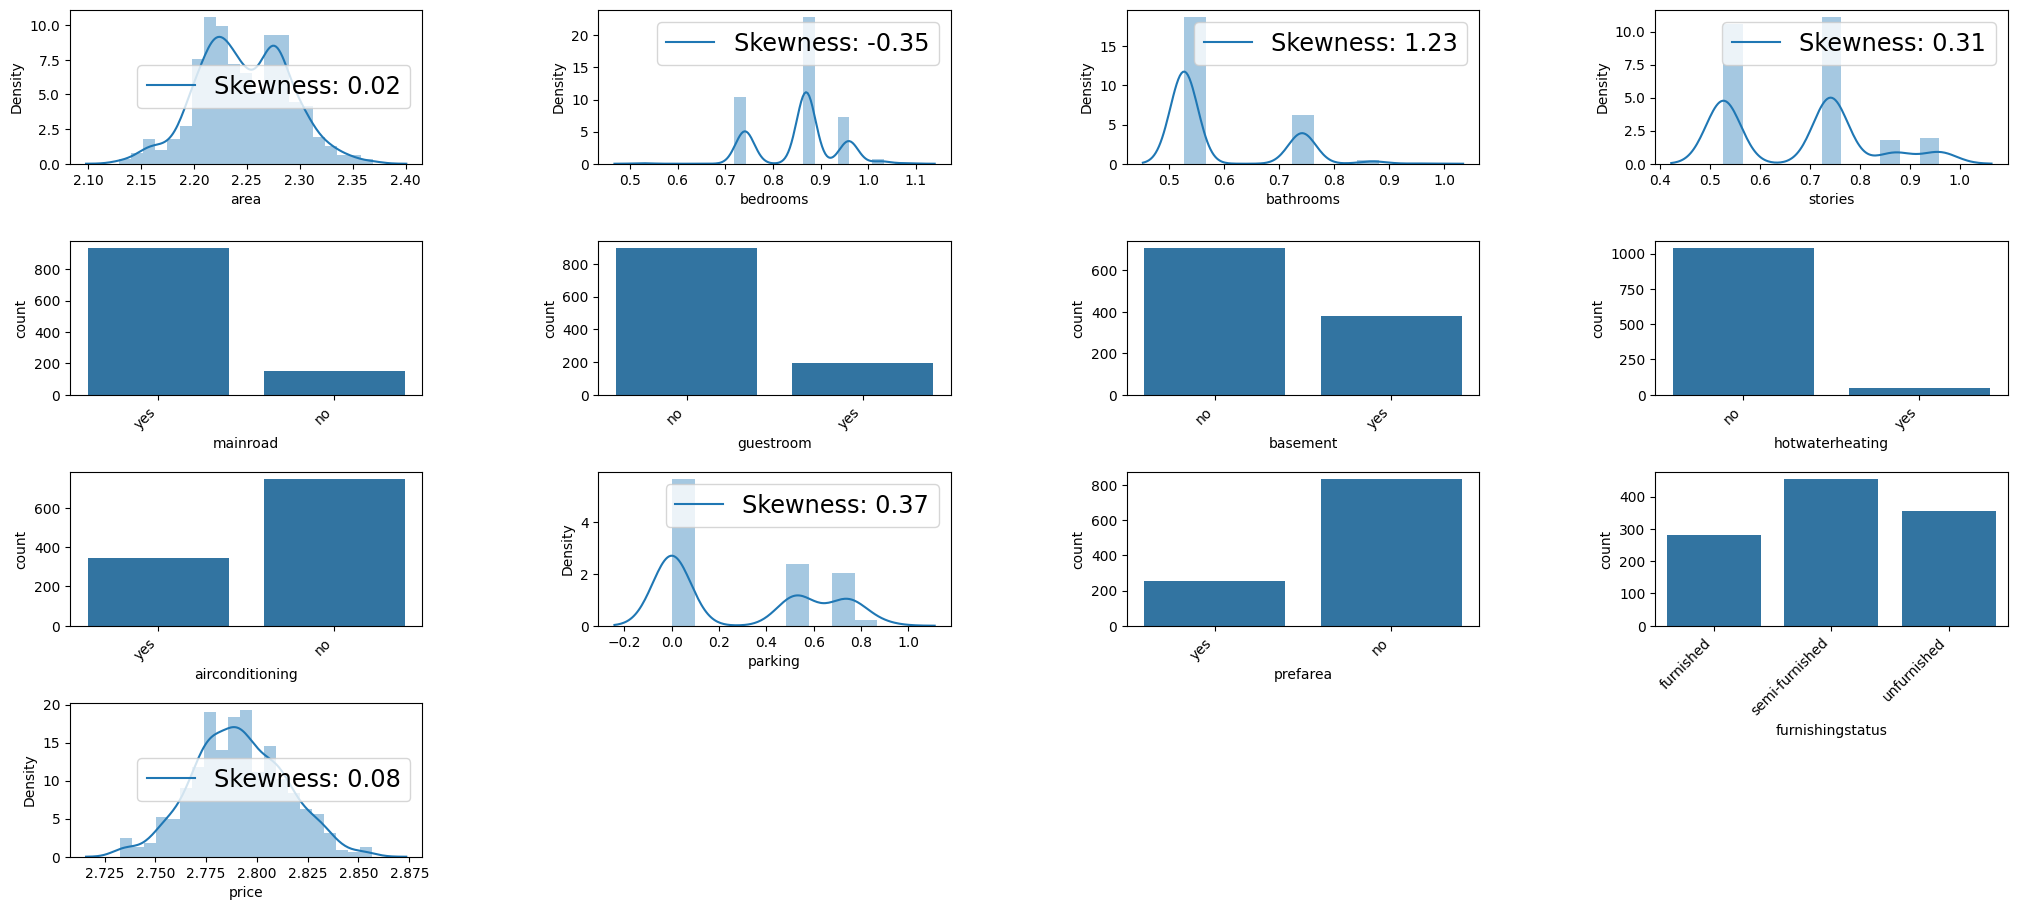

In [ ]:
plt.figure(figsize=(25,20))
for i in range(len(skewed_features)):
    if i<=28:
        plt.subplot(7,4,i+1)
        plt.subplots_adjust(hspace=0.5,wspace=0.5)

        # Check if the column contains numerical data before plotting
        if pd.api.types.is_numeric_dtype(df[skewed_features[i]]):
            ax=sns.distplot(df[skewed_features[i]])
            ax.legend(['Skewness: {:.2f}'.format(df[skewed_features[i]].skew())],fontsize='xx-large')
        else:
            # Handle categorical data differently, e.g., using a countplot
            ax = sns.countplot(x=df[skewed_features[i]], ax=plt.gca())  # Assign the countplot to ax
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

In [ ]:
price=np.log(train['price']+1)

In [ ]:
#get object feature to convert in numeric using dummy variable
obj_feat=list(df.loc[:,df.dtypes=='object'].columns.values)
len(obj_feat)

7

In [ ]:
#dummy variable
dummy_drop=[]
clean_df=df
for i in obj_feat:
    dummy_drop+=[i+'_'+str(df[i].unique()[-1])]
df=pd.get_dummies(df,columns=obj_feat)
df=df.drop(dummy_drop,axis=1)
df.shape

(1090, 14)

In [ ]:
df.shape

(1090, 14)

In [ ]:
#sns.pairplot(df)

In [ ]:
#scaling dataset with robust scaler
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
scaler.fit(df)
df=scaler.transform(df)

Machine Learning Model Building

In [ ]:
train_len=len(train)

In [ ]:
x_train = df[:train_len]
x_test = df[train_len:]
y_train = price

print(x_train.shape)
print(x_test.shape)
print(len(y_train))

(545, 14)
(545, 14)
545


cross validation

In [ ]:
from sklearn.model_selection import KFold,cross_val_score
from sklearn.metrics import make_scorer,r2_score

def test_model(model,x_train=x_train,y_train=y_train):
    cv=KFold(n_splits=3,shuffle=True,random_state=45)
    r2=make_scorer(r2_score)
    r2_val_score=cross_val_score(model,x_train,y_train,cv=cv,scoring=r2)
    score=[r2_val_score.mean()]
    return score

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
test_model(lr)

[np.float64(0.9997757718265774)]

Ridge Model

In [ ]:
from sklearn.linear_model import Ridge,Lasso
rdg=Ridge()
test_model(rdg)

[np.float64(0.9996686447094457)]

Lasso model

In [ ]:
lasso=Lasso(alpha=1e-4)
test_model(lasso)

[np.float64(0.9997800958087621)]


support vector machine

In [ ]:

from sklearn.svm import SVR

In [ ]:

svr_reg=SVR(kernel='rbf')
test_model(svr_reg)

[np.float64(0.9509887400017893)]

decision tree regression

*   List item
*   List item



In [ ]:

from sklearn.tree import DecisionTreeRegressor
dt_reg=DecisionTreeRegressor(random_state=21)
test_model(dt_reg)

[np.float64(0.9989569959992645)]

In [ ]:
from sklearn.tree import DecisionTreeRegressor # Assuming DecisionTreeRegressor is the intended model
# Instantiate the DecisionTreeRegressor model and assign it to the variable
model_house_price_prediction = DecisionTreeRegressor(random_state=21)

# Now you can call test_model with the instantiated model
test_model(model_house_price_prediction)

[np.float64(0.9989569959992645)]

In [ ]:
test_model(model_house_price_prediction)

[np.float64(0.9989569959992645)]

In [ ]:
import pickle
pickle.dump(lasso,open('/content/Housing.csv','wb'))
model_house_price_prediction=pickle.load(open('/content/Housing.csv','rb'))

In [ ]:
test_model(model_house_price_prediction)

[np.float64(0.9997800958087621)]